# Setup

**Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from loadmydata.load_human_locomotion import (
    load_human_locomotion_dataset,
    get_code_list,
)

**Utility functions**

In [2]:
def fig_ax(figsize=(15, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.autoscale(enable=True, axis='x', tight=True)
    return fig, ax

# Spectral feature

## Question 6

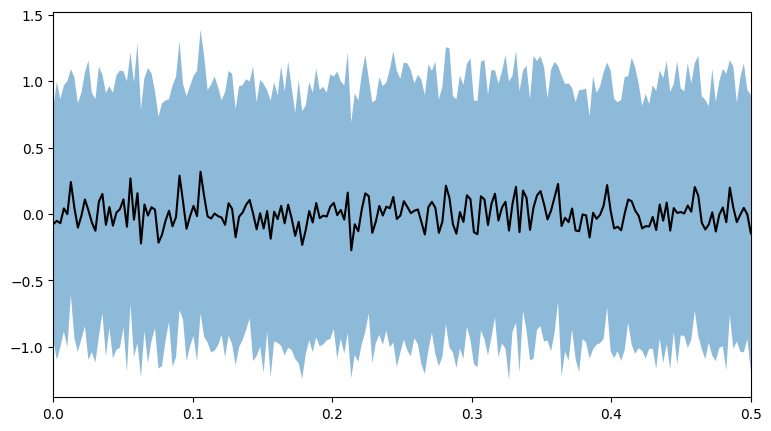

In [3]:
# This is an example of plot (random data). You can change it if you want.

## Change the following lines
periodograms = np.random.randn(100, 200)  # shape (n_trials, n_freqs)
freqs = np.linspace(0, 0.5, 200)
##


fig, ax = fig_ax(figsize=(9, 5))

avg = periodograms.mean(axis=0)
std = periodograms.std(axis=0)
ax.plot(freqs, avg, 'k-')
ax.fill_between(freqs, avg-std, avg+std, alpha=0.5)


**Answer**

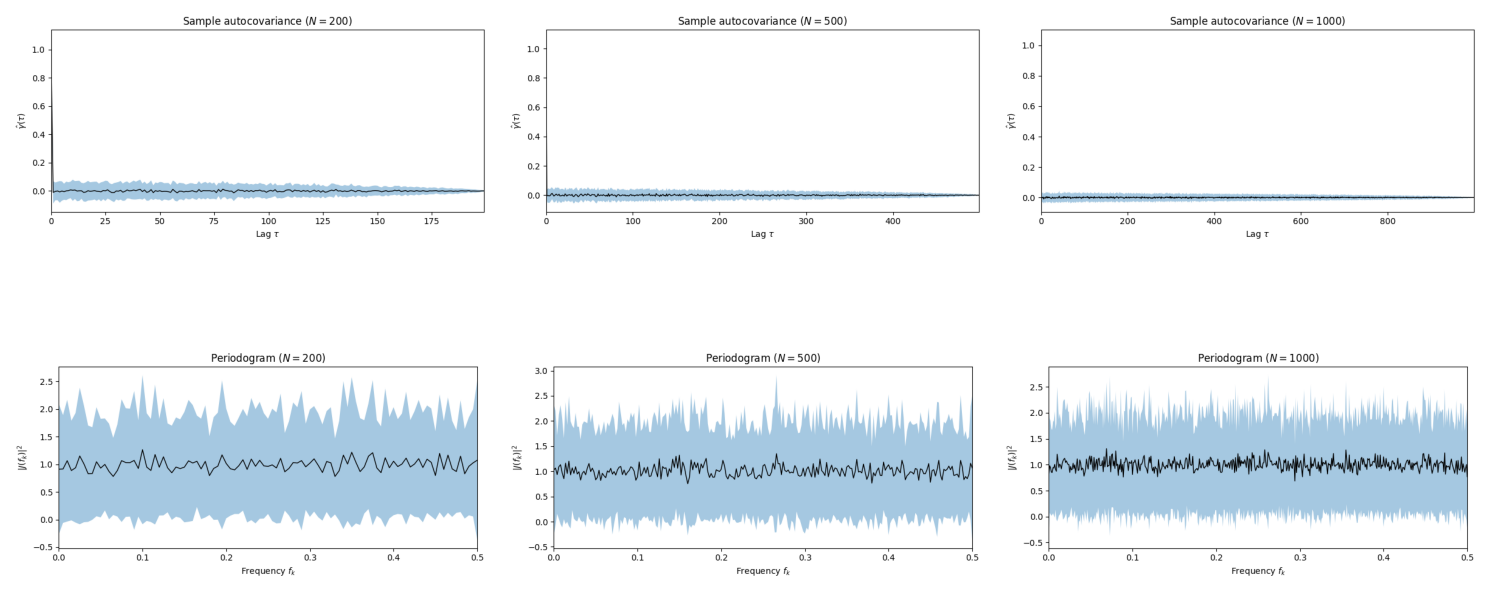

In [4]:
N_list = [200, 500, 1000]
n_trials = 100

for N in N_list:
    freqs = np.arange(N // 2 + 1) / N
    taus = np.arange(N)
    
    autocovs = []
    periodograms = []
    
    for _ in range(n_trials):
        X = np.random.randn(N)
        
        gamma_hat = np.array([
            (1 / N) * np.sum(X[:N - tau] * X[tau:])
            for tau in range(N)
        ])
        autocovs.append(gamma_hat)
        
        J = (1 / np.sqrt(N)) * np.fft.fft(X)
        P = np.abs(J[:N // 2 + 1])**2
        periodograms.append(P)
    
    autocovs = np.array(autocovs)
    periodograms = np.array(periodograms)
    
    # --- Autocovariance ---
    fig, ax = fig_ax(figsize=(8, 4))
    avg = autocovs.mean(axis=0)
    std = autocovs.std(axis=0)
    ax.plot(taus, avg, 'k-', lw=1)
    ax.fill_between(taus, avg - std, avg + std, alpha=0.4)
    ax.set_title(f"Sample autocovariance ($N={N}$)")
    ax.set_xlabel(r"Lag $\tau$")
    ax.set_ylabel(r"$\hat{\gamma}(\tau)$")
    fig.tight_layout()
    fig.savefig(f"autocovariance_N{N}.png", bbox_inches='tight') 
    plt.close(fig)

    # --- Periodogram ---
    fig, ax = fig_ax(figsize=(8, 4))
    avg = periodograms.mean(axis=0)
    std = periodograms.std(axis=0)
    ax.plot(freqs, avg, 'k-', lw=1)
    ax.fill_between(freqs, avg - std, avg + std, alpha=0.4)
    ax.set_title(f"Periodogram ($N={N}$)")
    ax.set_xlabel(r"Frequency $f_k$")
    ax.set_ylabel(r"$|J(f_k)|^2$")
    fig.tight_layout()
    fig.savefig(f"periodogram_N{N}.png", bbox_inches='tight')  
    plt.close(fig)
    

files = [
    "autocovariance_N200.png", "autocovariance_N500.png", "autocovariance_N1000.png",
    "periodogram_N200.png", "periodogram_N500.png", "periodogram_N1000.png"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, fname in zip(axes.ravel(), files):
    img = plt.imread(fname)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Question 9

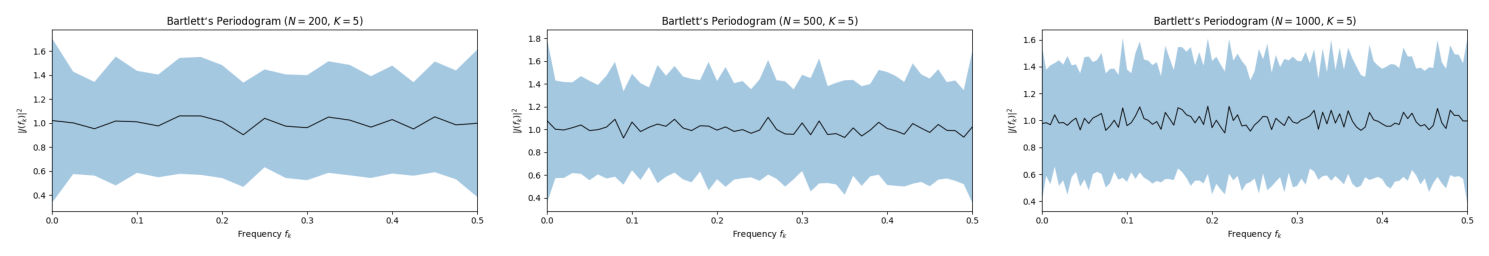

In [5]:
N_list = [200, 500, 1000]
n_trials = 100
K = 5

for N in N_list:
    L = N // K
    bartlett_periodograms = []

    for _ in range(n_trials):
        
        X = np.random.randn(N)

        segments = X.reshape(K, L)

        P_segments = []
        for k in range(K):
            X_seg = segments[k]
            J_seg = (1 / np.sqrt(L)) * np.fft.fft(X_seg)
            P_seg = np.abs(J_seg[:L // 2 + 1]) ** 2
            P_segments.append(P_seg)

        P_bartlett = np.mean(P_segments, axis=0)
        bartlett_periodograms.append(P_bartlett)

    bartlett_periodograms = np.array(bartlett_periodograms)
    freqs = np.arange(L // 2 + 1) / L  

    fig, ax = fig_ax(figsize=(8, 4))
    avg = bartlett_periodograms.mean(axis=0)
    std = bartlett_periodograms.std(axis=0)
    ax.plot(freqs, avg, 'k-', lw=1)
    ax.fill_between(freqs, avg - std, avg + std, alpha=0.4)
    ax.set_title(f"Bartlett’s Periodogram ($N={N}$, $K=5$)")
    ax.set_xlabel(r"Frequency $f_k$")
    ax.set_ylabel(r"$|J(f_k)|^2$")
    fig.tight_layout()
    fig.savefig(f"barlett_N{N}.png", bbox_inches='tight')
    plt.close(fig)

files = [
    "barlett_N200.png", "barlett_N500.png", "barlett_N1000.png"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for ax, fname in zip(axes.ravel(), files):
    img = plt.imread(fname)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()


# Dynamic time warping (DTW)

## Data

This data set consists of signals collected with inertial measurement units (accelerometer+gyroscope), from 230 subjects undergoing a fixed protocol:
- standing still,
- walking 10 m,
- turning around,
- walking back,
- stopping.

In this assignment, we only consider the vertical acceleration of the left foot and all signals are truncated to 20 seconds (as a result, they all have same length). Signals are sampled at 100 Hz.

The measured population is composed of healthy subjects as well as patients with neurological or orthopedic disorders.

The start and end time stamps of thousands of footsteps are available.

The data are part of a larger data set described in [1].

[1] Truong, C., Barrois-Müller, R., Moreau, T., Provost, C., Vienne-Jumeau, A., Moreau, A., Vidal, P.-P., Vayatis, N., Buffat, S., Yelnik, A., Ricard, D., & Oudre, L. (2019). A data set for the study of human locomotion with inertial measurements units. Image Processing On Line (IPOL), 9.

**The task** is to classify footsteps in healthy/non-healthy.

The following cell defines the training set `(X_train, y_train)` and testing set `(X_test, y_test)`.

In [6]:
subset_indexes_train = [95, 619, 441, 149, 951, 803, 214, 34, 37, 630]
subset_indexes_test = [683, 259, 59, 387, 634]

code_list = get_code_list()

X_train = list()  # list of footstep signals
y_train = list()  # list of pathologies (the "labels")

for code in np.take(code_list, subset_indexes_train):
    single_trial = load_human_locomotion_dataset(code)
    signal = single_trial.signal.LAZ.to_numpy()  # keeping only one dimension (from the left sensor)
    steps = single_trial.left_steps
    pathology = single_trial.metadata["PathologyGroup"]
    label = 0 if pathology=="Healthy" else 1  # 0: healthy, 1: non-healthy
    for (start, end) in steps:
        X_train.append(signal[start:end])
        y_train.append(label)

        
X_test = list()  # list of footstep signals
y_test = list()  # list of pathologies (the "labels")

for code in np.take(code_list, subset_indexes_test):
    single_trial = load_human_locomotion_dataset(code)
    signal = single_trial.signal.LAZ.to_numpy()  # keeping only one dimension (from the left sensor)
    steps = single_trial.left_steps
    pathology = single_trial.metadata["PathologyGroup"]
    label = 0 if pathology=="Healthy" else 1  # 0: healthy, 1: non-healthy
    for (start, end) in steps:
        X_test.append(signal[start:end])
        y_test.append(label)

- 0: healthy, 1: non healthy
- chaque élément de X_train est un pas individuel, de mm pour X_test, ils n'ont pas la mm taille (en fct du temps).


## Question 10

In [7]:
lengths_train = [len(x) for x in X_train]
lengths_test  = [len(x) for x in X_test]

print(f"Longueur moyenne des pas (train): {np.mean(lengths_train):.1f} ± {np.std(lengths_train):.1f}")
print(f"Longueur moyenne des pas (test):  {np.mean(lengths_test):.1f} ± {np.std(lengths_test):.1f}")
print(f"Min = {min(lengths_train)}, Max = {max(lengths_train)}")


Longueur moyenne des pas (train): 74.1 ± 8.6
Longueur moyenne des pas (test):  81.5 ± 17.4
Min = 32, Max = 99


In [8]:
X_train_norm = [(x - np.mean(x)) / np.std(x) for x in X_train]
X_test_norm  = [(x - np.mean(x)) / np.std(x) for x in X_test]

Text(0.5, 1.0, 'Normalized footsteps (zero mean, unit variance)')

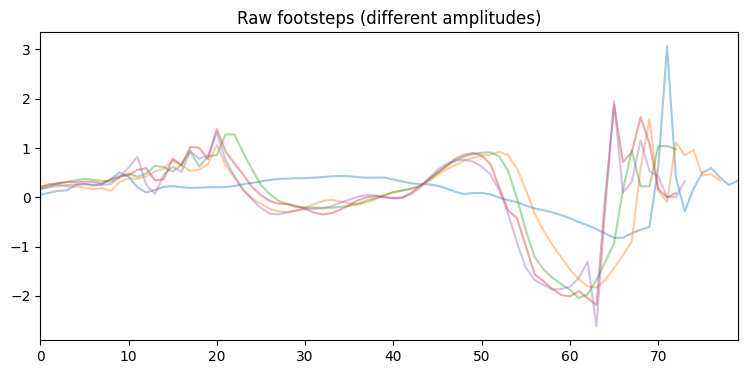

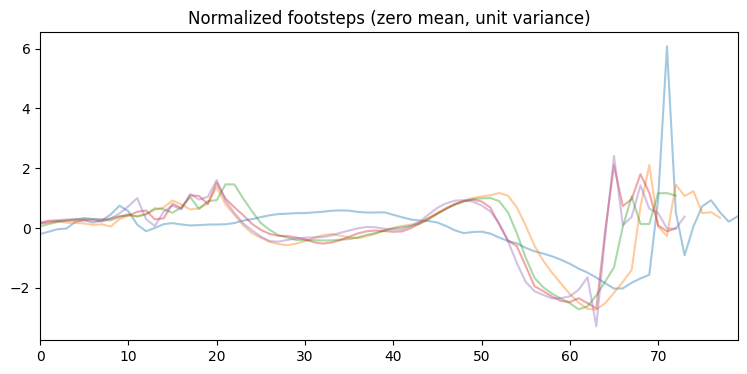

In [9]:
fig, ax = fig_ax(figsize=(9, 4))
for i in range(5):
    ax.plot(X_train[i], alpha=0.4)
ax.set_title("Raw footsteps (different amplitudes)")

fig, ax = fig_ax(figsize=(9, 4))
for i in range(5):
    ax.plot(X_train_norm[i], alpha=0.4)
ax.set_title("Normalized footsteps (zero mean, unit variance)")


In [10]:
from dtw import dtw

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [11]:
n_train = len(X_train_norm)
D_train = np.zeros((n_train, n_train))

print("Computing pairwise DTW distances on the training set...")
for i in range(n_train):
    for j in range(i + 1, n_train):
        dist= dtw(X_train_norm[i], X_train_norm[j], dist_method="euclidean").distance
        D_train[i, j] = D_train[j, i] = np.sqrt(dist)


Computing pairwise DTW distances on the training set...


In [12]:
from collections import Counter

def knn_predict(D, y_train, k):
    """
    Prend une matrice de distances D (distances entre test et train)
    et renvoie les prédictions k-NN.
    """
    preds = []
    for d in D:
        nearest = np.argsort(d)[:k]
        labels = [y_train[i] for i in nearest]
        pred = Counter(labels).most_common(1)[0][0]
        preds.append(pred)
    return np.array(preds)


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

ks = [1, 3, 5, 7, 9]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = []

for k in ks:
    f_scores = []
    for train_idx, val_idx in cv.split(D_train, y_train):
        D_sub = D_train[np.ix_(val_idx, train_idx)]
        y_pred = knn_predict(D_sub, np.array(y_train)[train_idx], k)
        f = f1_score(np.array(y_train)[val_idx], y_pred)
        f_scores.append(f)
    mean_f = np.mean(f_scores)
    scores.append(mean_f)
    print(f"k={k}: F1={mean_f:.3f}")

best_k = ks[np.argmax(scores)]
print(f"\n Best k = {best_k}, mean F1 = {max(scores):.3f}")


k=1: F1=0.874
k=3: F1=0.865
k=5: F1=0.872
k=7: F1=0.866
k=9: F1=0.868

 Best k = 1, mean F1 = 0.874


In [14]:
n_test = len(X_test_norm)
n_train = len(X_train_norm)
D_test = np.zeros((n_test, n_train))

print("Computing DTW distances between TEST and TRAIN...")
for i in range(n_test):
    for j in range(n_train):
        dist= dtw(X_test_norm[i], X_train_norm[j], dist_method="euclidean").distance
        D_test[i, j] = np.sqrt(dist)

print("D_test computed:", D_test.shape)


Computing DTW distances between TEST and TRAIN...
D_test computed: (88, 168)


In [15]:
for k in ks:
    y_test_pred=knn_predict(D_test,y_train,k=k)
    f1_test=f1_score(np.array(y_test), y_test_pred)
    print(f"Test F1-score (k={k}): {f1_test:.3f}")

Test F1-score (k=1): 0.562
Test F1-score (k=3): 0.500
Test F1-score (k=5): 0.460
Test F1-score (k=7): 0.478
Test F1-score (k=9): 0.504


## Question 11

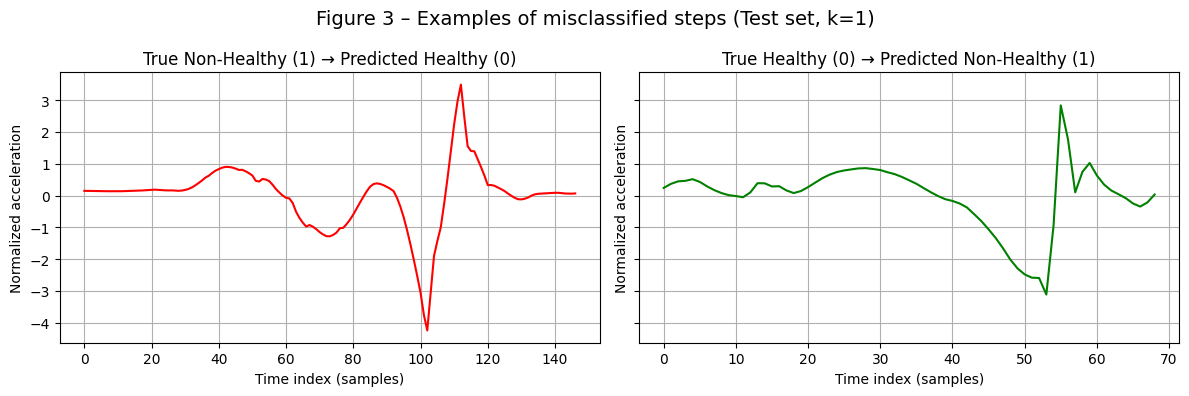

In [16]:
idx_true1_pred0 = np.where((np.array(y_test) == 1) & (np.array(y_test_pred) == 0))[0]  # non-healthy → healthy
idx_true0_pred1 = np.where((np.array(y_test) == 0) & (np.array(y_test_pred) == 1))[0]  # healthy → non-healthy

bad_nonhealthy = idx_true1_pred0[0] if len(idx_true1_pred0) > 0 else None
bad_healthy    = idx_true0_pred1[0] if len(idx_true0_pred1) > 0 else None


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

if bad_nonhealthy is not None:
    axes[0].plot(X_test_norm[bad_nonhealthy], color='red')
    axes[0].set_title("True Non-Healthy (1) → Predicted Healthy (0)")
else:
    axes[0].set_title("No Non-Healthy→Healthy misclassification")

if bad_healthy is not None:
    axes[1].plot(X_test_norm[bad_healthy], color='green')
    axes[1].set_title("True Healthy (0) → Predicted Non-Healthy (1)")
else:
    axes[1].set_title("No Healthy→Non-Healthy misclassification")

for ax in axes:
    ax.set_xlabel("Time index (samples)")
    ax.set_ylabel("Normalized acceleration")
    ax.grid(True)

plt.suptitle("Figure 3 – Examples of misclassified steps (Test set, k=1)", fontsize=14)
plt.tight_layout()
plt.savefig("figure3_misclassified_steps.png", dpi=300, bbox_inches='tight')
plt.show()

# === SSaving figures ===
if bad_nonhealthy is not None:
    plt.figure(figsize=(6, 3))
    plt.plot(X_test_norm[bad_nonhealthy], color='red')
    plt.title("True Non-Healthy (1) → Predicted Healthy (0)")
    plt.xlabel("Time index (samples)")
    plt.ylabel("Normalized acceleration")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("badly_classified_nonhealthy.png", dpi=300, bbox_inches='tight')
    plt.close()

if bad_healthy is not None:
    plt.figure(figsize=(6, 3))
    plt.plot(X_test_norm[bad_healthy], color='green')
    plt.title("True Healthy (0) → Predicted Non-Healthy (1)")
    plt.xlabel("Time index (samples)")
    plt.ylabel("Normalized acceleration")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("badly_classified_healthy.png", dpi=300, bbox_inches='tight')
    plt.close()
